In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

SEED = 42
np.random.seed(SEED)  # reproducibilidad

df = pd.read_csv("Call_Center_Data.csv")

def time_to_minutes(t):
    try:
        h, m, s = map(int, str(t).split(":"))
        return h*60 + m + s/60
    except:
        return np.nan

df["Talk Duration (AVG)"] = df["Talk Duration (AVG)"].apply(time_to_minutes)

simulation_time = 480

calls_per_period = df["Incoming Calls"].mean()
lambda_per_minute = calls_per_period / simulation_time

mean_service = df["Talk Duration (AVG)"].mean()
std_service = df["Talk Duration (AVG)"].std()

In [2]:
def simulate_call_center(num_agents):

    current_time = 0
    agents = [0] * num_agents

    waiting_times = []
    abandoned_calls = 0
    answered_calls = 0

    while current_time < simulation_time:

        interarrival = np.random.exponential(scale=1/lambda_per_minute)
        current_time += interarrival

        if current_time > simulation_time:
            break

        service_time = max(0.1, np.random.normal(mean_service, std_service))

        next_free_time = min(agents)

        if next_free_time <= current_time:
            agent_index = agents.index(next_free_time)
            agents[agent_index] = current_time + service_time

            waiting_times.append(0)
            answered_calls += 1

        else:
            wait_time = next_free_time - current_time

            patience = np.random.exponential(scale=3)

            if wait_time > patience:
                abandoned_calls += 1
            else:
                agent_index = agents.index(next_free_time)
                agents[agent_index] = next_free_time + service_time

                waiting_times.append(wait_time)
                answered_calls += 1


    if len(waiting_times) > 0:
        avg_wait = np.mean(waiting_times)
        service_level = sum(1 for w in waiting_times if w < 0.33) / len(waiting_times)
    else:
        avg_wait = 0
        service_level = 0

    return {
        "answered": answered_calls,
        "abandoned": abandoned_calls,
        "avg_wait": avg_wait,
        "service_level": service_level
    }

In [3]:
simulations = 500

agents_list = [2, 3, 5, 10]

final_results = []

for agents in agents_list:

    results = [simulate_call_center(agents) for _ in range(simulations)]
    df_res = pd.DataFrame(results)

    summary = {
        "agents": agents,
        "answered": df_res["answered"].mean(),
        "abandoned": df_res["abandoned"].mean(),
        "avg_wait": df_res["avg_wait"].mean(),
        "service_level": df_res["service_level"].mean() * 100
    }

    final_results.append(summary)

results_df = pd.DataFrame(final_results)

print("\n===== COMPARACION DE ESCENARIOS =====\n")
print(results_df)


===== COMPARACION DE ESCENARIOS =====

   agents  answered  abandoned  avg_wait  service_level
0       2   180.424     18.138  0.225009      81.500958
1       3   194.192      4.128  0.051528      94.798575
2       5   197.796      0.174  0.002010      99.776777
3      10   198.552      0.000  0.000000     100.000000


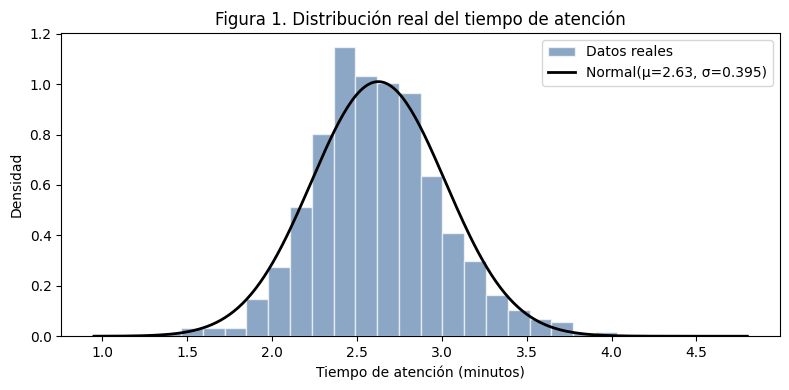

In [4]:
data = df["Talk Duration (AVG)"].dropna()
x_vals = np.linspace(data.min(), data.max(), 300)

plt.figure(figsize=(8, 4))
plt.hist(data, bins=30, density=True, color="#4e79a7", alpha=0.65, edgecolor="white", label="Datos reales")
plt.plot(x_vals, stats.norm.pdf(x_vals, mean_service, std_service), "k-", lw=2,
         label=f"Normal(μ={mean_service:.2f}, σ={std_service:.3f})")
plt.title("Figura 1. Distribución real del tiempo de atención")
plt.xlabel("Tiempo de atención (minutos)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

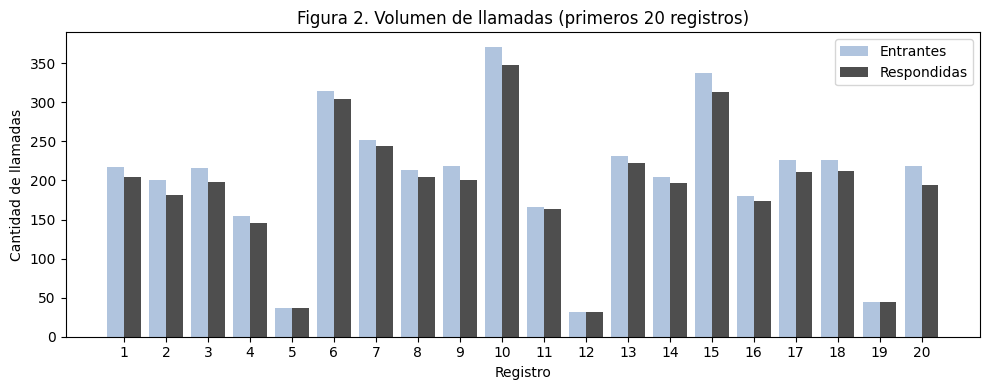

In [5]:
n = min(20, len(df))
x = np.arange(1, n + 1)
w = 0.4
inc = df["Incoming Calls"].iloc[:n].values
ans = df["Answered Calls"].iloc[:n].values

plt.figure(figsize=(10, 4))
plt.bar(x - w/2, inc, w, color="#b0c4de", label="Entrantes")
plt.bar(x + w/2, ans, w, color="#4e4e4e", label="Respondidas")
plt.title("Figura 2. Volumen de llamadas (primeros 20 registros)")
plt.xlabel("Registro")
plt.ylabel("Cantidad de llamadas")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()

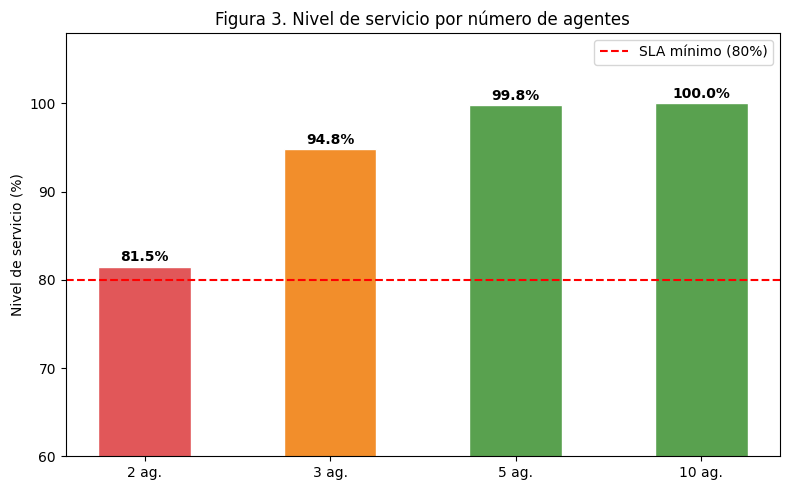

In [6]:
colores = ["#e15759" if sl < 90 else "#f28e2b" if sl < 98 else "#59a14f"
           for sl in results_df["service_level"]]

plt.figure(figsize=(8, 5))
bars = plt.bar(results_df["agents"].astype(str) + " ag.", results_df["service_level"],
               color=colores, edgecolor="white", width=0.5)
plt.axhline(80, color="red", linestyle="--", lw=1.5, label="SLA mínimo (80%)")
for bar, val in zip(bars, results_df["service_level"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.title("Figura 3. Nivel de servicio por número de agentes")
plt.ylabel("Nivel de servicio (%)")
plt.ylim(60, 108)
plt.legend()
plt.tight_layout()
plt.show()

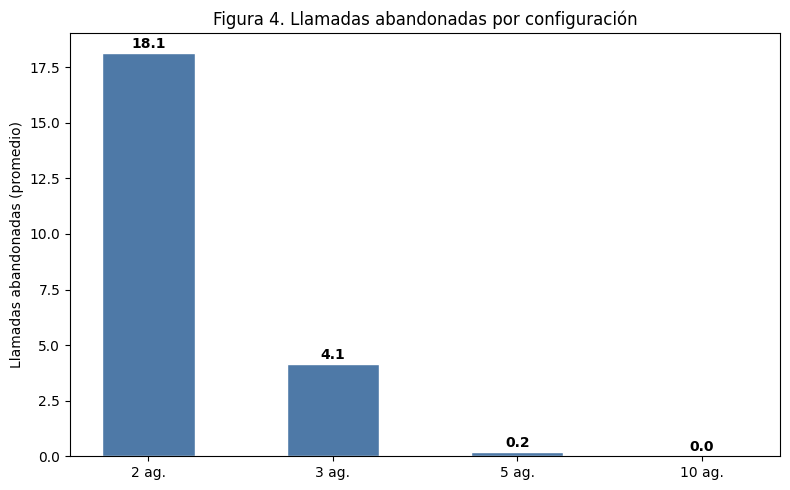

In [7]:
plt.figure(figsize=(8, 5))
bars2 = plt.bar(results_df["agents"].astype(str) + " ag.", results_df["abandoned"],
                color="#4e79a7", edgecolor="white", width=0.5)
for bar, val in zip(bars2, results_df["abandoned"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.title("Figura 4. Llamadas abandonadas por configuración")
plt.ylabel("Llamadas abandonadas (promedio)")
plt.tight_layout()
plt.show()

In [8]:
agents_wi = [3, 5, 7]
escenarios = [
    ("Base (normal)",        1.0,  1.0),
    ("Alta demanda (+30%)",  1.30, 1.0),
    ("Mayor duración (+20%)", 1.0, 1.20),
]

all_wi = []
for nombre, lf, sf in escenarios:
    lam_wi = lambda_per_minute * lf
    mu_wi  = mean_service * sf
    for n_ag in agents_wi:
        reps = []
        for _ in range(simulations):
            current_time = 0
            agents = [0] * n_ag
            waiting_times = []
            abandoned_calls = 0
            answered_calls = 0
            while current_time < simulation_time:
                current_time += np.random.exponential(1.0 / lam_wi)
                if current_time > simulation_time:
                    break
                service_time = max(0.1, np.random.normal(mu_wi, std_service))
                next_free_time = min(agents)
                if next_free_time <= current_time:
                    agents[agents.index(next_free_time)] = current_time + service_time
                    waiting_times.append(0)
                    answered_calls += 1
                else:
                    wait_time = next_free_time - current_time
                    if wait_time > np.random.exponential(3):
                        abandoned_calls += 1
                    else:
                        agents[agents.index(next_free_time)] = next_free_time + service_time
                        waiting_times.append(wait_time)
                        answered_calls += 1
            sl = sum(1 for w in waiting_times if w < 0.33) / len(waiting_times) if waiting_times else 0
            reps.append({"abandoned": abandoned_calls, "avg_wait": np.mean(waiting_times) if waiting_times else 0, "service_level": sl})
        df_r = pd.DataFrame(reps)
        all_wi.append({
            "escenario": nombre,
            "agents": n_ag,
            "abandoned": df_r["abandoned"].mean(),
            "avg_wait": df_r["avg_wait"].mean(),
            "service_level": df_r["service_level"].mean() * 100
        })

df_wi = pd.DataFrame(all_wi)
print(df_wi)

               escenario  agents  abandoned  avg_wait  service_level
0          Base (normal)       3      4.126  0.052497      94.737016
1          Base (normal)       5      0.178  0.001961      99.774338
2          Base (normal)       7      0.002  0.000020      99.996571
3    Alta demanda (+30%)       3      9.838  0.095185      90.673449
4    Alta demanda (+30%)       5      0.490  0.005224      99.394172
5    Alta demanda (+30%)       7      0.012  0.000149      99.982024
6  Mayor duración (+20%)       3      6.938  0.087556      91.997264
7  Mayor duración (+20%)       5      0.362  0.005140      99.447074
8  Mayor duración (+20%)       7      0.004  0.000091      99.989306


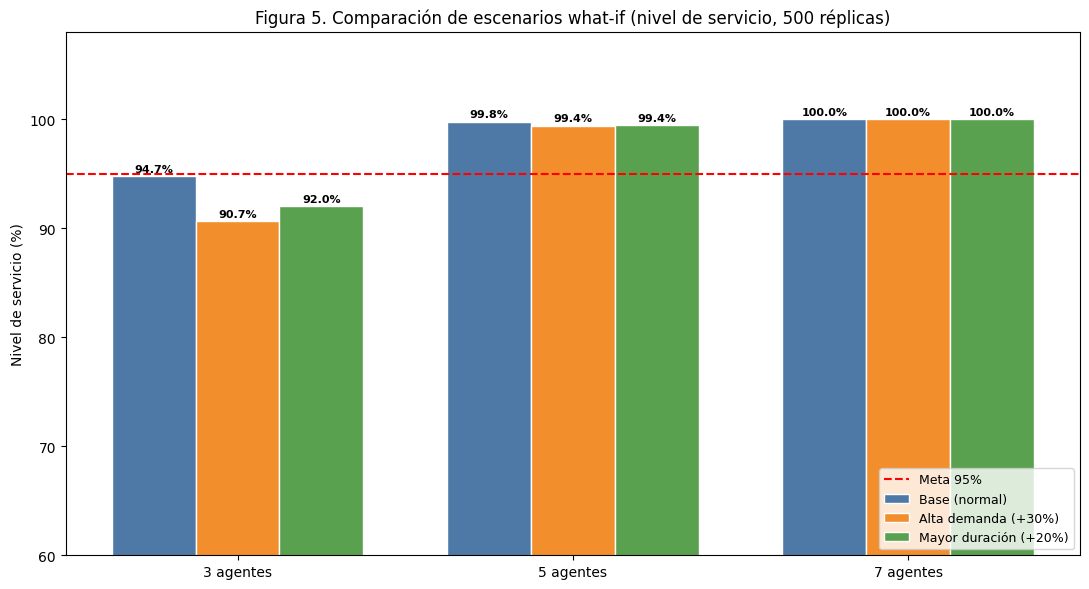

In [9]:
x_wi  = np.arange(len(agents_wi))
width = 0.25
pal   = ["#4e79a7", "#f28e2b", "#59a14f"]

plt.figure(figsize=(11, 6))
for i, (nombre, _, __) in enumerate(escenarios):
    subset = df_wi[df_wi["escenario"] == nombre]
    bars_w = plt.bar(x_wi + i * width, subset["service_level"],
                     width, label=nombre, color=pal[i], edgecolor="white")
    for bar, val in zip(bars_w, subset["service_level"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
plt.axhline(95, color="red", linestyle="--", lw=1.5, label="Meta 95%")
plt.xticks(x_wi + width, [f"{a} agentes" for a in agents_wi])
plt.title("Figura 5. Comparación de escenarios what-if (nivel de servicio, 500 réplicas)")
plt.ylabel("Nivel de servicio (%)")
plt.ylim(60, 108)
plt.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

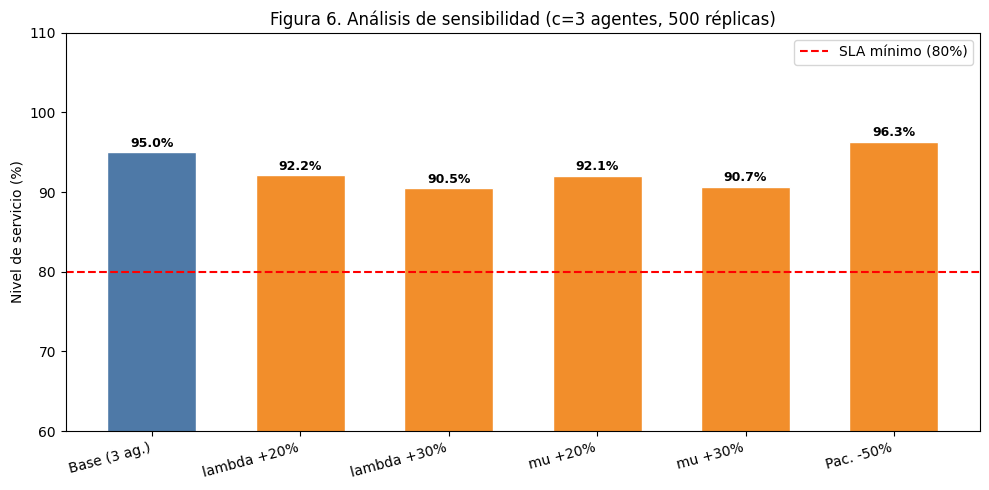

In [10]:
casos = [
    ("Base (3 ag.)", lambda_per_minute,        mean_service,        3.0),
    ("lambda +20%",  lambda_per_minute * 1.20, mean_service,        3.0),
    ("lambda +30%",  lambda_per_minute * 1.30, mean_service,        3.0),
    ("mu +20%",      lambda_per_minute,        mean_service * 1.20, 3.0),
    ("mu +30%",      lambda_per_minute,        mean_service * 1.30, 3.0),
    ("Pac. -50%",    lambda_per_minute,        mean_service,        1.5),
]

labels_s, sl_s = [], []
for nombre, lam, mu, pat in casos:
    reps = []
    for _ in range(simulations):
        current_time = 0
        agents = [0] * 3
        waiting_times = []
        while current_time < simulation_time:
            current_time += np.random.exponential(1.0 / lam)
            if current_time > simulation_time:
                break
            service_time = max(0.1, np.random.normal(mu, std_service))
            next_free_time = min(agents)
            if next_free_time <= current_time:
                agents[agents.index(next_free_time)] = current_time + service_time
                waiting_times.append(0)
            else:
                wait_time = next_free_time - current_time
                if wait_time <= np.random.exponential(pat):
                    agents[agents.index(next_free_time)] = next_free_time + service_time
                    waiting_times.append(wait_time)
        sl = sum(1 for w in waiting_times if w < 0.33) / len(waiting_times) if waiting_times else 0
        reps.append(sl)
    labels_s.append(nombre)
    sl_s.append(np.mean(reps) * 100)

colores_s = ["#4e79a7"] + ["#f28e2b"] * 5
plt.figure(figsize=(10, 5))
bars_s = plt.bar(labels_s, sl_s, color=colores_s, edgecolor="white", width=0.6)
plt.axhline(80, color="red", linestyle="--", lw=1.5, label="SLA mínimo (80%)")
for bar, val in zip(bars_s, sl_s):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.title("Figura 6. Análisis de sensibilidad (c=3 agentes, 500 réplicas)")
plt.ylabel("Nivel de servicio (%)")
plt.ylim(60, 110)
plt.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()